# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Muhammad Dzaky Haidar | 5054251039 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

sns.set_theme(style="whitegrid")

In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("bankruptcy.csv")
df.columns = df.columns.str.strip()

print("Jumlah baris dan kolom:", df.shape)
display(df.head())
df.info()
display(df.describe())
display(df.isna().sum().rename("Missing value").to_frame())

Jumlah baris dan kolom: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate 

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


,Missing value
Bankrupt?,0
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
...,...
Liability to Equity,0
Degree of Financial Leverage (DFL),0
Interest Coverage Ratio (Interest expense to EBIT),0
Net Income Flag,0


,count
Bankrupt?,
0,6599
1,220


,proportion
Bankrupt?,
0,96.77372
1,3.22628


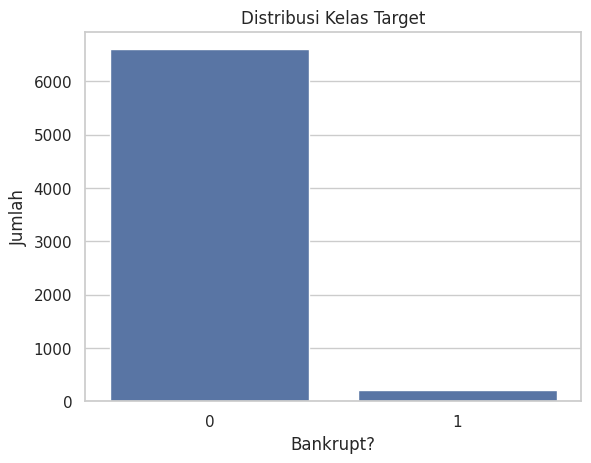

In [4]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
display(df["Bankrupt?"].value_counts().sort_index())
display(df["Bankrupt?"].value_counts(normalize=True).sort_index() * 100)

sns.countplot(data=df, x="Bankrupt?")
plt.title("Distribusi Kelas Target")
plt.ylabel("Jumlah")
plt.show()

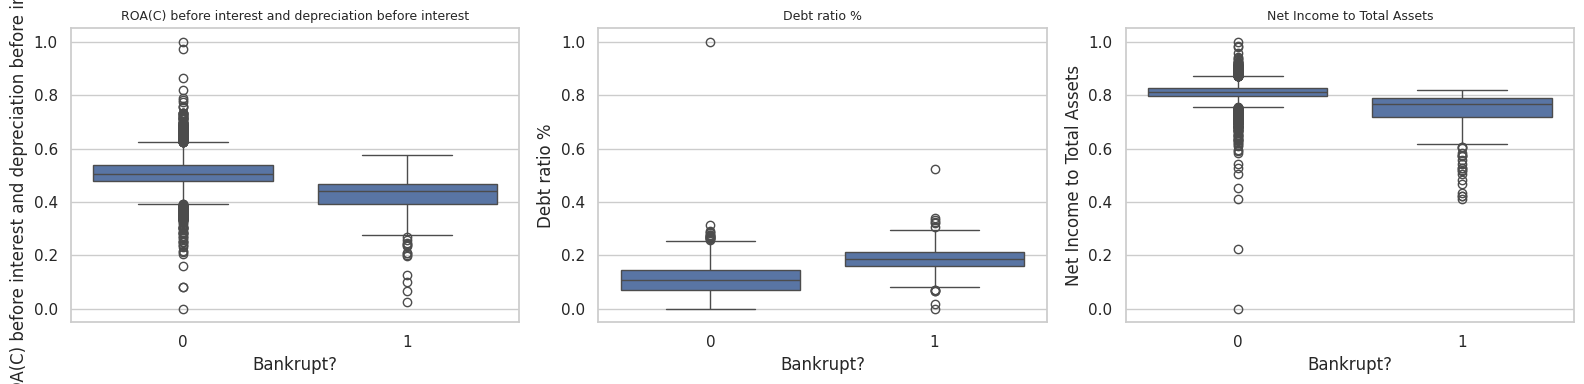

In [5]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
fitur_eda = [
    "ROA(C) before interest and depreciation before interest",
    "Debt ratio %",
    "Net Income to Total Assets"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for fitur, ax in zip(fitur_eda, axes):
    sns.boxplot(data=df, x="Bankrupt?", y=fitur, ax=ax)
    ax.set_title(fitur, fontsize=9)

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [6]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df = df.dropna(subset=["Bankrupt?"]).copy()
print("Total Missing Value:", df.drop(columns="Bankrupt?").isna().sum().sum())
imputer = SimpleImputer(strategy="median")

Total Missing Value: 0


In [7]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
kolom_categorical = df.select_dtypes(exclude="number").columns.tolist()
print("Kolom Categorical:", kolom_categorical)

Kolom Categorical: []


In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns="Bankrupt?")
y = df["Bankrupt?"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns,index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns,index=X_test.index)

print("Train:", X_train.shape)
print("Test:",X_test.shape)

Train: (5455, 95)
Test: (1364, 95)


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [9]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
model_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
model_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [10]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
pred_gini = model_gini.predict(X_test)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [11]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
model_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
pred_entropy = model_entropy.predict(X_test)

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [13]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).

f1_gini = f1_score(y_test, pred_gini, zero_division=0)
f1_entropy = f1_score(y_test, pred_entropy, zero_division=0)

best_kriteria = "gini" if f1_gini >= f1_entropy else "entropy"
best_model = model_gini if best_kriteria == "gini" else model_entropy

depths = [1,2,3,5,10,None]
model_depth = {}

for depth in depths:
    model = DecisionTreeClassifier(criterion=best_kriteria, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    model_depth[depth] = model

print("Kriteria terbaik:", best_kriteria)

Kriteria terbaik: entropy


In [14]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
hasil_depth = pd.DataFrame([{
    "max_depth": str(depth),
    "Train": accuracy_score(y_train, model.predict(X_train)),
    "Test": accuracy_score(y_test, model.predict(X_test))
}
for depth, model in model_depth.items()
])


hasil_depth["Gap"] = hasil_depth["Train"] - hasil_depth["Test"]
display(hasil_depth)

,max_depth,Train,Test,Gap
0,1,0.967736,0.967742,-0.000006
1,2,0.967736,0.967742,-0.000006
2,3,0.968286,0.969941,-0.001655
3,5,0.974335,0.966276,0.008060
4,10,0.993034,0.963343,0.029691
5,None,1.000000,0.964076,0.035924


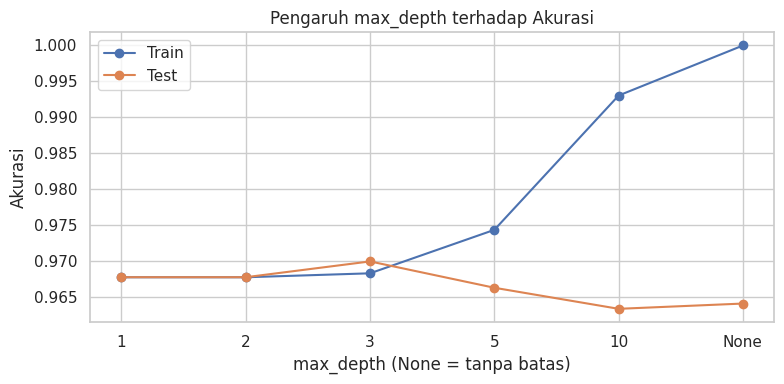

In [16]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(8, 4))

plt.plot(hasil_depth["max_depth"], hasil_depth["Train"], "o-", label="Train")
plt.plot(hasil_depth["max_depth"], hasil_depth["Test"], "o-", label="Test")

plt.xlabel("max_depth (None = tanpa batas)")
plt.ylabel("Akurasi")
plt.title("Pengaruh max_depth terhadap Akurasi")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [17]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
hasil_evaluasi = pd.DataFrame([
    {
        "Model": nama,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0)
    }
    for nama, pred in [("Gini", pred_gini), ("Entropy", pred_entropy)]
]).set_index("Model")

display(hasil_evaluasi.round(4))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Gini,0.9604,0.3864,0.3864,0.3864
Entropy,0.9641,0.4359,0.3864,0.4096


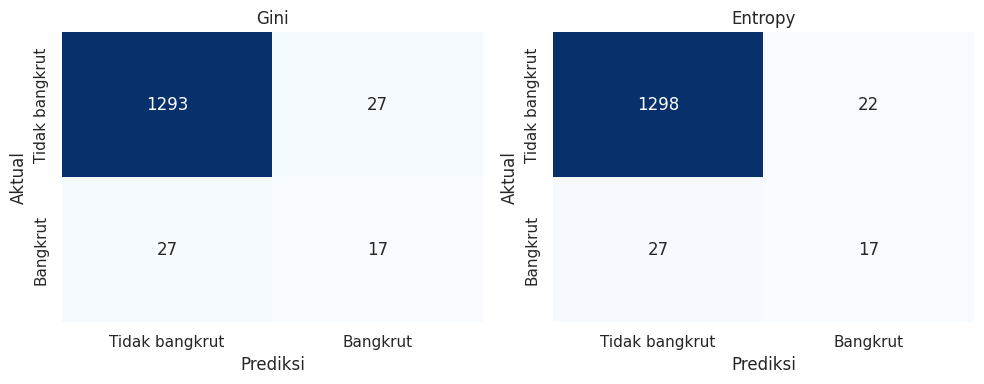

In [18]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, nama, pred in zip(
    axes, ["Gini", "Entropy"], [pred_gini, pred_entropy]
):
    sns.heatmap(
        confusion_matrix(y_test, pred, labels=[0, 1]),
        annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Tidak bangkrut", "Bangkrut"],
        yticklabels=["Tidak bangkrut", "Bangkrut"],
        ax=ax
    )
    ax.set_title(nama)
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")

plt.tight_layout()
plt.show()

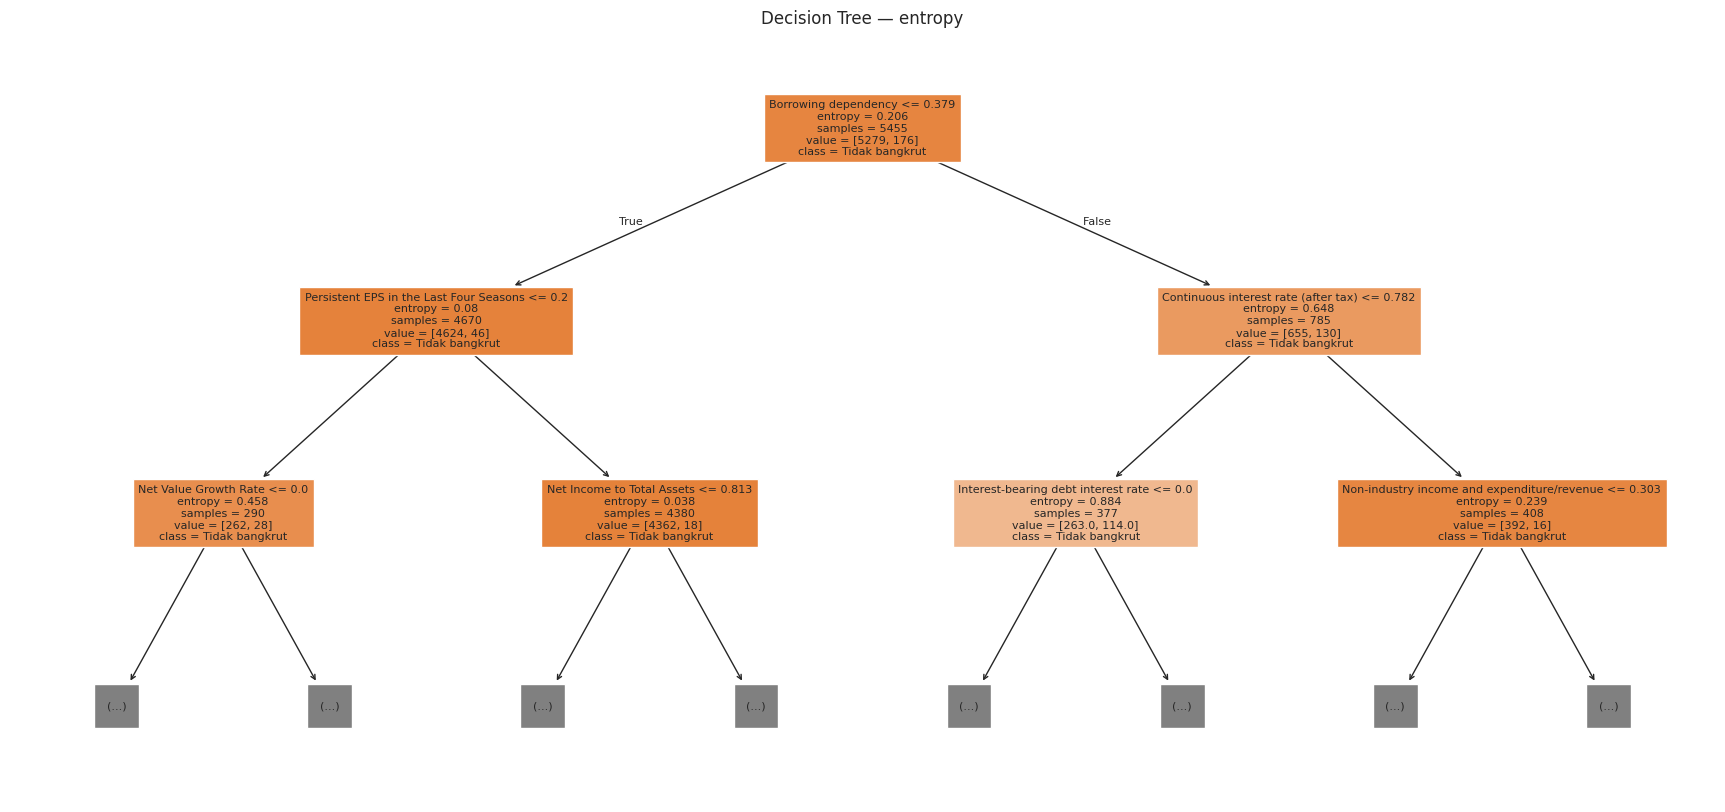

In [20]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
plt.figure(figsize=(22, 10))

plot_tree(
    best_model,
    feature_names=X.columns.tolist(),
    class_names=["Tidak bangkrut", "Bangkrut"],
    filled=True,
    max_depth=2,
    fontsize=8
)

plt.title(f"Decision Tree — {best_kriteria}")
plt.show()

,Importance
Borrowing dependency,0.222147
Continuous interest rate (after tax),0.075791
Persistent EPS in the Last Four Seasons,0.063519
Net Value Growth Rate,0.051659
Quick Ratio,0.029765
Operating Profit Growth Rate,0.026979
Net Income to Total Assets,0.024663
Interest-bearing debt interest rate,0.024218
Operating Expense Rate,0.022477
Non-industry income and expenditure/revenue,0.018859


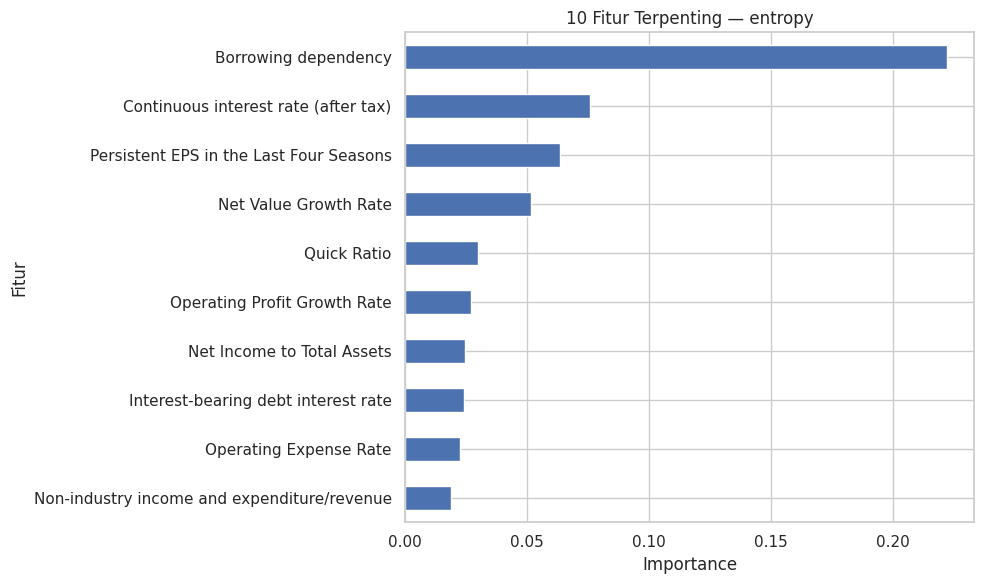

In [21]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(importance.head(10).rename("Importance").to_frame())

importance.head(10).sort_values().plot.barh(figsize=(10, 6))
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.title(f"10 Fitur Terpenting — {best_kriteria}")
plt.tight_layout()
plt.show()

# 5. Analisis

### Adapun hasil dari Analisis berdasarkan Eksperimen saya:

- Model Entropy menghasilkan accuracy 96,41%, precision 43,59%, recall 38,64%, dan F1-score 40,96%. Model Gini menghasilkan accuracy 96,04%, precision 38,64%, recall 38,64%, dan F1-score 38,64%.
- Entropy lebih unggul berdasarkan F1-score, tetapi selisih performanya relatif kecil. Perbedaan ini dapat terjadi karena Gini dan Entropy menghitung ketidakmurnian node dengan cara berbeda sehingga pemisahan datanya dapat berbeda.
- Accuracy kedua model tinggi, tetapi recall kelas bangkrut masih rendah. Keduanya hanya mendeteksi sekitar 38,64% perusahaan yang benar-benar bangkrut. Karena dataset tidak seimbang, accuracy saja belum cukup untuk menilai kemampuan model.
- Pada eksperimen regularisasi, max_depth=3 menghasilkan akurasi testing tertinggi, yaitu 96,99%, dengan akurasi training 96,83%.
- Gejala overfitting mulai terlihat pada max_depth=5: akurasi training meningkat menjadi 97,43%, sedangkan akurasi testing turun menjadi 96,63%.
- Overfitting semakin terlihat pada max_depth=10 dan tanpa batas kedalaman. Pada kedalaman tanpa batas, akurasi training mencapai 100%, tetapi akurasi testing hanya 96,41%.
- Fitur paling berpengaruh pada model Entropy adalah Borrowing dependency dengan importance sekitar 22,21%, diikuti Continuous interest rate (after tax) sebesar 7,58% dan Persistent EPS in the Last Four Seasons sebesar 6,35%.
- Feature importance menunjukkan kontribusi fitur terhadap pemisahan pada model, bukan hubungan sebab-akibat terhadap kebangkrutan.

# 6. Kesimpulan dan Saran

### Kesimpulan dari Eksperimen ini adalah:

- Decision Tree dengan kriteria Entropy memberikan hasil lebih baik daripada Gini berdasarkan F1-score pada eksperimen ini.
- Pembatasan kedalaman membantu mengurangi overfitting. Dari variasi yang diuji, max_depth=3 memberikan akurasi testing tertinggi, tetapi kemampuan mendeteksi kelas bangkrut pada kedalaman ini masih perlu diperiksa melalui precision, recall, dan F1-score.
- Model belum optimal dalam mendeteksi perusahaan bangkrut karena recall kelas tersebut masih rendah meskipun accuracy tinggi.
- Eksperimen berikutnya dapat mencoba class_weight="balanced" untuk meningkatkan perhatian model terhadap kelas bangkrut, kemudian mengevaluasi perubahan precision dan recall.
- Regularisasi tambahan dapat dilakukan dengan mencoba min_samples_leaf, min_samples_split, atau pruning menggunakan ccp_alpha.
- Gunakan Stratified Cross-Validation pada data training untuk memilih hyperparameter, lalu gunakan test set hanya untuk evaluasi akhir.
- Bandingkan hasil Decision Tree dengan model lain, seperti Random Forest, untuk mengetahui apakah kemampuan mendeteksi kebangkrutan dapat ditingkatkan.